# Day 4 - Performance Analytics

## Task 1: Compute Daily Returns

Objective:
Compute daily returns for all 40 mutual fund schemes using NAV history.

Formula:

Daily Return = (NAV_t / NAV_(t-1)) - 1

Deliverable:
returns_computed.csv

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [6]:
import sqlite3

conn = sqlite3.connect("mutual_funds.db")

In [7]:
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,dim_fund
1,fact_nav
2,fact_aum
3,fact_sip
4,fact_transactions
5,fact_holdings
6,fact_benchmark
7,fact_category_inflows
8,fact_folio_count
9,fact_scheme_performance


In [8]:
query = """
SELECT *
FROM fact_nav
"""

nav_df = pd.read_sql(query, conn)

nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [10]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [11]:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

In [12]:
nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [13]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [14]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

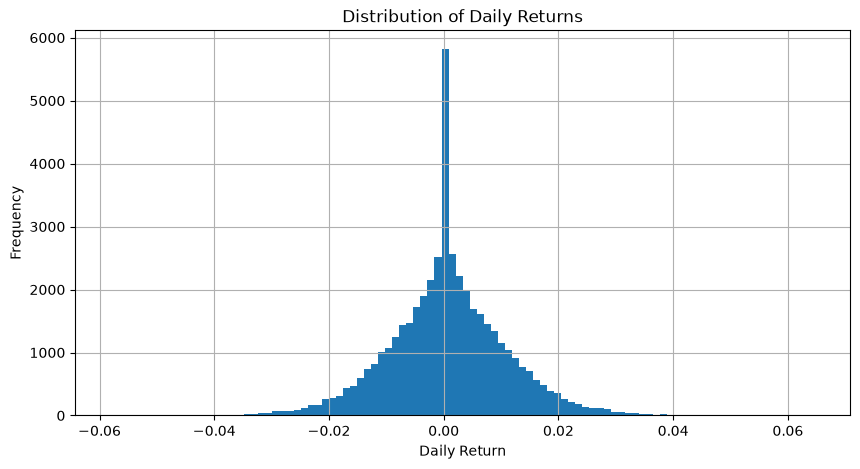

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav_df["daily_return"].dropna().hist(bins=100)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [16]:
import os

os.makedirs("../reports/day4", exist_ok=True)

nav_df.to_csv(
    "../reports/day4/returns_computed.csv",
    index=False
)

print("Daily Returns Computed Successfully")

Daily Returns Computed Successfully


# Task 2 – CAGR Calculation

## Objective

Compute Compound Annual Growth Rate (CAGR) for each mutual fund over:

- 1 Year
- 3 Years
- 5 Years

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) - 1

Deliverable:
cagr_report.csv

In [17]:
latest_date = nav_df["date"].max()

print("Latest NAV Date:", latest_date)

Latest NAV Date: 2026-05-29 00:00:00


In [18]:
def calculate_cagr(df, years):
    
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_nav = (
        df[df["date"] >= start_date]
        .sort_values("date")
        .iloc[0]["nav"]
    )

    end_nav = (
        df.sort_values("date")
        .iloc[-1]["nav"]
    )

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr

In [19]:
cagr_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ]

    cagr_1 = calculate_cagr(fund_df, 1)
    cagr_3 = calculate_cagr(fund_df, 3)
    cagr_5 = calculate_cagr(fund_df, 5)

    cagr_list.append({
        "amfi_code": fund,
        "CAGR_1Y": cagr_1,
        "CAGR_3Y": cagr_3,
        "CAGR_5Y": cagr_5
    })

In [20]:
cagr_df = pd.DataFrame(cagr_list)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [21]:
cagr_df["CAGR_1Y"] *= 100
cagr_df["CAGR_3Y"] *= 100
cagr_df["CAGR_5Y"] *= 100

In [22]:
cagr_df = cagr_df.round(2)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [23]:
cagr_df = cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,22.26,35.11,24.45
34,148567,20.36,34.00,26.80
24,120504,13.06,32.49,20.23
2,100033,53.23,32.44,26.07
25,120505,29.60,31.78,28.38
19,119551,60.44,30.46,22.38
30,120843,26.66,29.58,26.74
36,148569,39.75,29.18,27.63
3,101206,47.92,28.97,20.44
39,149324,65.14,27.00,27.92


In [24]:
cagr_df.to_csv(
    "../reports/day4/cagr_report.csv",
    index=False
)

print("CAGR Report Saved Successfully")

CAGR Report Saved Successfully


Task 3 – Sharpe Ratio

## Objective

Measure risk-adjusted performance of each mutual fund.

Risk-Free Rate:

6.5% (RBI repo rate proxy)

Formula:

Sharpe = (Rp − Rf) / Std(Returns) × √252

Deliverable:

sharpe_values.csv

In [25]:
import numpy as np

RISK_FREE_RATE = 0.065

In [26]:
sharpe_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ]

    returns = fund_df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (annual_return - RISK_FREE_RATE) / annual_volatility

    sharpe_list.append({
        "amfi_code": fund,
        "Sharpe_Ratio": sharpe
    })

In [27]:
sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [28]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(ascending=False, method="dense")
)

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Rank"
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [29]:
sharpe_df["Sharpe_Ratio"] = sharpe_df["Sharpe_Ratio"].round(4)

sharpe_df.head()

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.4483,1.0
30,120843,1.3067,2.0
36,148569,1.2349,3.0
19,119551,1.2083,4.0
25,120505,1.1801,5.0


In [30]:
sharpe_df.to_csv(
    "../reports/day4/sharpe_values.csv",
    index=False
)

print("Sharpe Ratio Report Saved Successfully")

Sharpe Ratio Report Saved Successfully


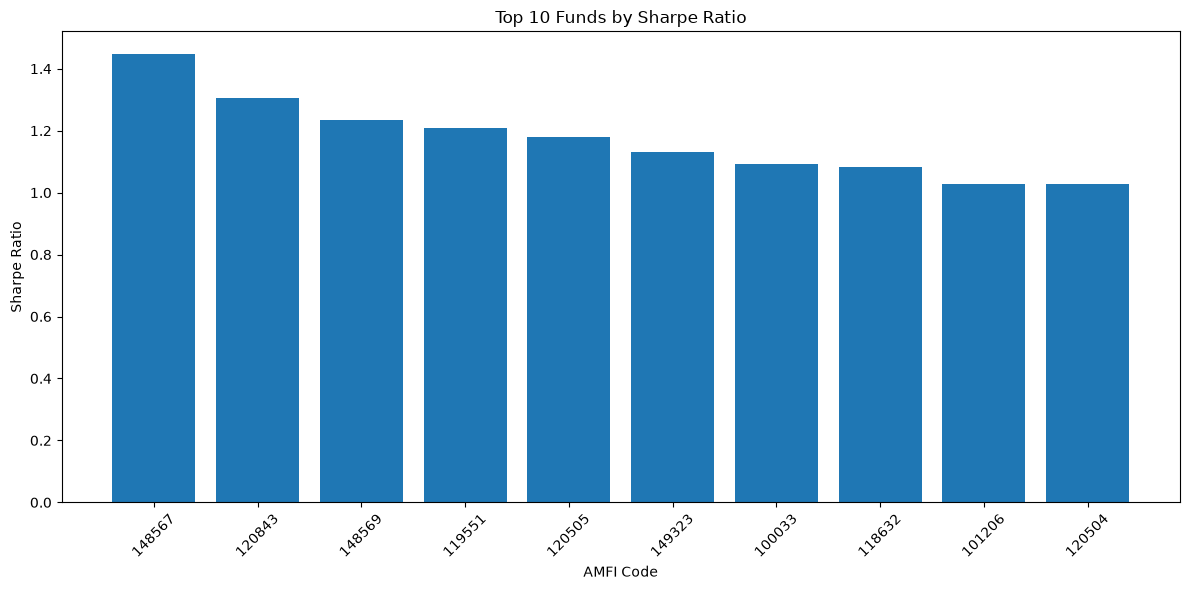

In [33]:
import matplotlib.pyplot as plt

top10 = sharpe_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [36]:
import os

os.makedirs("reports/charts", exist_ok=True)

In [37]:
plt.savefig(
    "reports/charts/sharpe_ratio_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

# Task 4 – Sortino Ratio

## Objective

Measure the risk-adjusted performance of mutual funds using downside volatility.

Risk-Free Rate:
6.5%

Formula:

Sortino Ratio = ((Mean Annual Return − Risk-Free Rate) / Downside Deviation)

Deliverable:
sortino_values.csv

In [38]:
RISK_FREE_RATE = 0.065

In [39]:
sortino_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ]

    returns = fund_df["daily_return"].dropna()

    if len(returns) == 0:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_deviation = np.nan
    else:
        downside_deviation = (
            downside_returns.std() * np.sqrt(252)
        )

    if pd.isna(downside_deviation) or downside_deviation == 0:
        sortino = np.nan
    else:
        sortino = (
            annual_return - RISK_FREE_RATE
        ) / downside_deviation

    sortino_list.append({
        "amfi_code": fund,
        "Sortino_Ratio": sortino
    })

In [40]:
sortino_df = pd.DataFrame(sortino_list)

sortino_df.head()

,amfi_code,Sortino_Ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [41]:
sortino_df["Sortino_Rank"] = (
    sortino_df["Sortino_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

sortino_df = sortino_df.sort_values(
    "Sortino_Rank"
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [42]:
sortino_df["Sortino_Ratio"] = (
    sortino_df["Sortino_Ratio"]
    .round(4)
)

sortino_df.head()

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.3856,1.0
30,120843,2.3643,2.0
36,148569,2.1469,3.0
19,119551,2.1403,4.0
25,120505,2.0294,5.0


In [44]:
import os

os.makedirs("reports", exist_ok=True)
os.makedirs("reports/day4", exist_ok=True)
os.makedirs("reports/charts", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [45]:
sortino_df.to_csv(
    "reports/day4/sortino_values.csv",
    index=False
)

print("Sortino Ratio Report Saved Successfully")

Sortino Ratio Report Saved Successfully


In [46]:
benchmark_df = pd.read_sql(
    "SELECT * FROM fact_benchmark",
    conn
)

benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [48]:
benchmark_df["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

# Task 5 – Alpha & Beta

## Objective

Calculate Alpha and Beta of each mutual fund against the NIFTY100 benchmark.

Method:
- Compute daily returns for benchmark.
- Merge benchmark returns with fund returns.
- Perform linear regression using scipy.stats.linregress.
- Annualize Alpha by multiplying intercept by 252.

Deliverables:
- alpha_beta.csv
- alpha_beta_top10.png

In [49]:
from scipy.stats import linregress

In [50]:
benchmark = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [51]:
alpha_beta = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_df,
        benchmark[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund,
        "Alpha": intercept * 252,
        "Beta": slope,
        "R_Squared": r_value**2
    })

In [52]:
alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.037476,-0.058268,0.002665
1,100025,0.042818,0.001158,0.000015
2,100033,0.271954,0.005104,0.000012
3,101206,0.213998,0.021086,0.000348
4,101207,0.108971,-0.065289,0.001064


In [53]:
alpha_beta_df = alpha_beta_df.round(4)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared
0,100016,0.0375,-0.0583,0.0027
1,100025,0.0428,0.0012,0.0000
2,100033,0.2720,0.0051,0.0000
3,101206,0.2140,0.0211,0.0003
4,101207,0.1090,-0.0653,0.0011


In [54]:
alpha_beta_df.to_csv(
    "reports/day4/alpha_beta.csv",
    index=False
)

print("Alpha Beta Report Saved Successfully")

Alpha Beta Report Saved Successfully


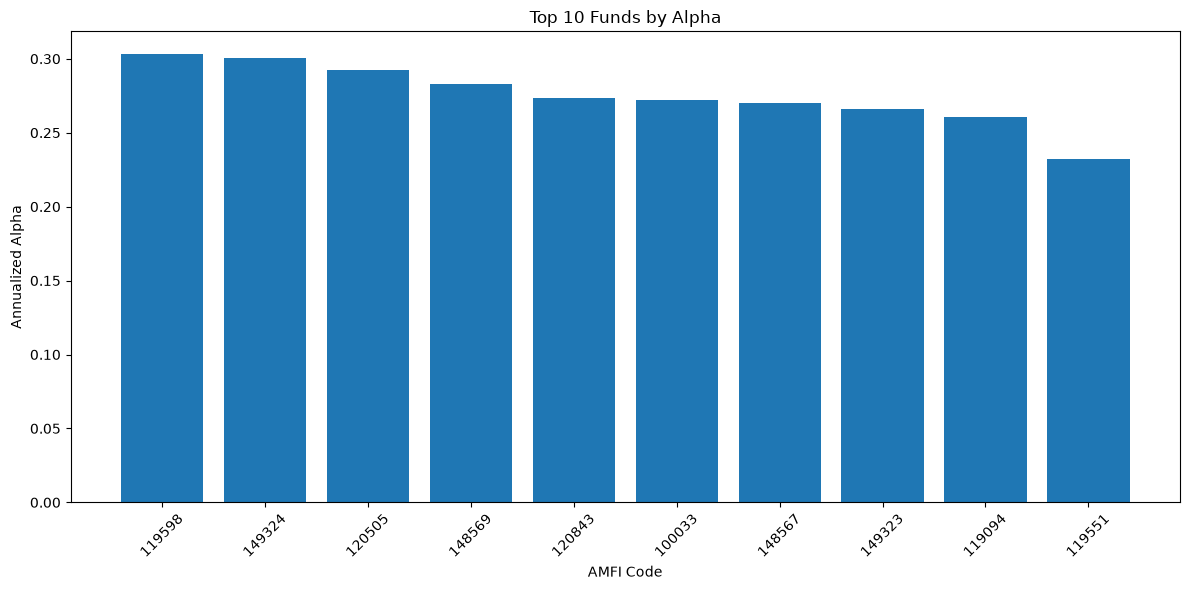

In [55]:
top10 = alpha_beta_df.sort_values(
    "Alpha",
    ascending=False
).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Alpha"]
)

plt.title("Top 10 Funds by Alpha")

plt.xlabel("AMFI Code")

plt.ylabel("Annualized Alpha")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [58]:

plt.savefig(
    "reports/charts/alpha_top10.png",
    dpi=300,
    bbox_inches="tight"
)



<Figure size 640x480 with 0 Axes>

# Task 6 – Maximum Drawdown

## Objective

Calculate the Maximum Drawdown (MDD) for every mutual fund.

Formula

Drawdown = NAV / Running Maximum NAV - 1

Maximum Drawdown = Minimum Drawdown

Deliverables

- max_drawdown.csv
- max_drawdown_top10.png

In [59]:
drawdown_list = []

for fund in nav_df["amfi_code"].unique():

    fund_df = nav_df[
        nav_df["amfi_code"] == fund
    ].copy()

    fund_df = fund_df.sort_values("date")

    fund_df["Running_Max"] = fund_df["nav"].cummax()

    fund_df["Drawdown"] = (
        fund_df["nav"] / fund_df["Running_Max"]
    ) - 1

    max_dd = fund_df["Drawdown"].min()

    max_dd_date = fund_df.loc[
        fund_df["Drawdown"].idxmin(),
        "date"
    ]

    drawdown_list.append({
        "amfi_code": fund,
        "Maximum_Drawdown": max_dd,
        "Worst_Date": max_dd_date
    })

In [60]:
drawdown_df = pd.DataFrame(drawdown_list)

drawdown_df.head()

,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [61]:
drawdown_df["Maximum_Drawdown"] = (
    drawdown_df["Maximum_Drawdown"] * 100
)

drawdown_df = drawdown_df.round(2)

drawdown_df.head()

C:\Users\Ruchita\AppData\Local\Temp\ipykernel_204\1347960342.py:5: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  drawdown_df = drawdown_df.round(2)


,amfi_code,Maximum_Drawdown,Worst_Date
0,100016,-24.73,2022-09-15
1,100025,-4.31,2023-07-28
2,100033,-16.22,2022-05-12
3,101206,-11.29,2023-07-05
4,101207,-35.45,2026-05-11


In [62]:
drawdown_df["Drawdown_Rank"] = (
    drawdown_df["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

drawdown_df = drawdown_df.sort_values(
    "Maximum_Drawdown",
    ascending=False
)

drawdown_df.head(10)

,amfi_code,Maximum_Drawdown,Worst_Date,Drawdown_Rank
27,120507,-0.10,2025-10-20,1.0
31,120844,-0.12,2024-04-30,2.0
5,101208,-0.16,2023-09-12,3.0
1,100025,-4.31,2023-07-28,4.0
18,119120,-4.33,2025-04-01,5.0
13,118636,-8.32,2024-02-09,6.0
6,102885,-10.86,2022-03-29,7.0
34,148567,-11.27,2023-10-20,8.0
3,101206,-11.29,2023-07-05,9.0
12,118635,-11.65,2022-06-09,10.0


In [63]:
drawdown_df.to_csv(
    "reports/day4/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown Report Saved Successfully")

Maximum Drawdown Report Saved Successfully


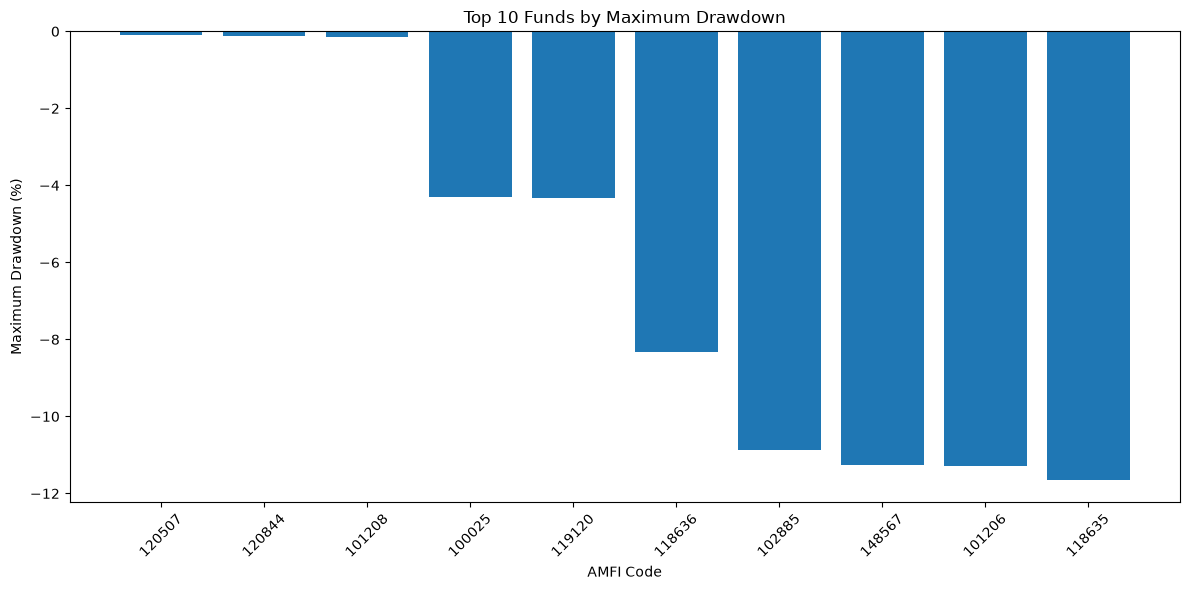

In [64]:
top10 = drawdown_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Maximum_Drawdown"]
)

plt.title("Top 10 Funds by Maximum Drawdown")

plt.xlabel("AMFI Code")

plt.ylabel("Maximum Drawdown (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [65]:
plt.savefig(
    "reports/charts/max_drawdown_top10.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# Task 7 – Fund Scorecard

## Objective

Create a composite score (0–100) for every mutual fund using multiple performance metrics.

Weights

- 30% × 3-Year CAGR Rank
- 25% × Sharpe Rank
- 20% × Alpha Rank
- 15% × Expense Ratio Rank (Inverse)
- 10% × Maximum Drawdown Rank (Inverse)

Deliverables

- fund_scorecard.csv
- fund_scorecard_top10.png

In [67]:
pd.read_sql(
    "SELECT * FROM dim_fund LIMIT 5",
    conn
)

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [68]:
fund_columns = pd.read_sql(
    "PRAGMA table_info(dim_fund);",
    conn
)

fund_columns

,cid,name,type,notnull,dflt_value,pk
0,0,amfi_code,INTEGER,0,None,0
1,1,fund_house,TEXT,0,None,0
2,2,scheme_name,TEXT,0,None,0
3,3,category,TEXT,0,None,0
4,4,sub_category,TEXT,0,None,0
5,5,plan,TEXT,0,None,0
6,6,launch_date,TEXT,0,None,0
7,7,benchmark,TEXT,0,None,0
8,8,expense_ratio_pct,REAL,0,None,0
9,9,exit_load_pct,REAL,0,None,0


In [69]:
fund_df = pd.read_sql(
    """
    SELECT
        amfi_code,
        expense_ratio_pct
    FROM dim_fund
    """,
    conn
)

fund_df.head()

,amfi_code,expense_ratio_pct
0,119551,1.54
1,119552,0.66
2,119598,1.43
3,119599,0.72
4,119120,0.77


In [70]:
fund_df["Expense_Rank"] = (
    fund_df["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

fund_df.head()

,amfi_code,expense_ratio_pct,Expense_Rank
0,119551,1.54,24.0
1,119552,0.66,4.0
2,119598,1.43,18.0
3,119599,0.72,5.0
4,119120,0.77,8.0


In [72]:
print("cagr_df:", 'cagr_df' in globals())
print("sharpe_df:", 'sharpe_df' in globals())
print("alpha_beta_df:", 'alpha_beta_df' in globals())
print("drawdown_df:", 'drawdown_df' in globals())
print("fund_df:", 'fund_df' in globals())

cagr_df: True
sharpe_df: True
alpha_beta_df: True
drawdown_df: True
fund_df: True


In [74]:
alpha_beta_df.columns

Index(['amfi_code', 'Alpha', 'Beta', 'R_Squared'], dtype='str')

In [75]:
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,R_Squared,Alpha_Rank
0,100016,0.0375,-0.0583,0.0027,39.0
1,100025,0.0428,0.0012,0.0000,38.0
2,100033,0.2720,0.0051,0.0000,6.0
3,101206,0.2140,0.0211,0.0003,12.0
4,101207,0.1090,-0.0653,0.0011,27.0


In [77]:
score_df = cagr_df.copy()

score_df = score_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    alpha_beta_df[["amfi_code", "Alpha_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    drawdown_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    fund_df[["amfi_code", "Expense_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Expense_Rank
0,119094,22.26,35.11,24.45,11.0,9.0,28.0,15.0
1,148567,20.36,34.00,26.80,1.0,7.0,8.0,20.0
2,120504,13.06,32.49,20.23,10.0,13.0,12.0,11.0
3,100033,53.23,32.44,26.07,7.0,6.0,20.0,15.0
4,120505,29.60,31.78,28.38,5.0,3.0,25.0,14.0


In [78]:
cagr_df["CAGR_Rank"] = (
    cagr_df["CAGR_3Y"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [79]:
alpha_beta_df["Alpha_Rank"] = (
    alpha_beta_df["Alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [80]:
sharpe_df["Sharpe_Rank"] = (
    sharpe_df["Sharpe_Ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [81]:
drawdown_df["Drawdown_Rank"] = (
    drawdown_df["Maximum_Drawdown"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [82]:
fund_df["Expense_Rank"] = (
    fund_df["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [83]:
score_df = cagr_df.copy()

score_df = score_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    alpha_beta_df[["amfi_code", "Alpha_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    drawdown_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    fund_df[["amfi_code", "Expense_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Expense_Rank
0,119094,22.26,35.11,24.45,1.0,11.0,9.0,28.0,15.0
1,148567,20.36,34.00,26.80,2.0,1.0,7.0,8.0,20.0
2,120504,13.06,32.49,20.23,3.0,10.0,13.0,12.0,11.0
3,100033,53.23,32.44,26.07,4.0,7.0,6.0,20.0,15.0
4,120505,29.60,31.78,28.38,5.0,5.0,3.0,25.0,14.0


In [84]:
print(cagr_df.columns)
print(sharpe_df.columns)
print(alpha_beta_df.columns)
print(drawdown_df.columns)
print(fund_df.columns)

Index(['amfi_code', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'CAGR_Rank'], dtype='str')
Index(['amfi_code', 'Sharpe_Ratio', 'Sharpe_Rank'], dtype='str')
Index(['amfi_code', 'Alpha', 'Beta', 'R_Squared', 'Alpha_Rank'], dtype='str')
Index(['amfi_code', 'Maximum_Drawdown', 'Worst_Date', 'Drawdown_Rank'], dtype='str')
Index(['amfi_code', 'expense_ratio_pct', 'Expense_Rank'], dtype='str')


In [85]:
score_df = cagr_df.merge(
    sharpe_df[["amfi_code", "Sharpe_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    alpha_beta_df[["amfi_code", "Alpha_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    drawdown_df[["amfi_code", "Drawdown_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df = score_df.merge(
    fund_df[["amfi_code", "Expense_Rank"]],
    on="amfi_code",
    how="inner"
)

score_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Expense_Rank
0,119094,22.26,35.11,24.45,1.0,11.0,9.0,28.0,15.0
1,148567,20.36,34.00,26.80,2.0,1.0,7.0,8.0,20.0
2,120504,13.06,32.49,20.23,3.0,10.0,13.0,12.0,11.0
3,100033,53.23,32.44,26.07,4.0,7.0,6.0,20.0,15.0
4,120505,29.60,31.78,28.38,5.0,5.0,3.0,25.0,14.0


In [86]:
max_rank = score_df[
    ["CAGR_Rank", "Sharpe_Rank", "Alpha_Rank", "Expense_Rank", "Drawdown_Rank"]
].max().max()

score_df["Fund_Score"] = (
    ((max_rank - score_df["CAGR_Rank"] + 1) / max_rank) * 30 +
    ((max_rank - score_df["Sharpe_Rank"] + 1) / max_rank) * 25 +
    ((max_rank - score_df["Alpha_Rank"] + 1) / max_rank) * 20 +
    ((max_rank - score_df["Expense_Rank"] + 1) / max_rank) * 15 +
    ((max_rank - score_df["Drawdown_Rank"] + 1) / max_rank) * 10
)

score_df["Fund_Score"] = (
    score_df["Fund_Score"] / score_df["Fund_Score"].max()
) * 100

score_df["Fund_Score"] = score_df["Fund_Score"].round(2)

score_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,CAGR_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Expense_Rank,Fund_Score
0,119094,22.26,35.11,24.45,1.0,11.0,9.0,28.0,15.0,88.98
1,148567,20.36,34.00,26.80,2.0,1.0,7.0,8.0,20.0,100.00
2,120504,13.06,32.49,20.23,3.0,10.0,13.0,12.0,11.0,91.99
3,100033,53.23,32.44,26.07,4.0,7.0,6.0,20.0,15.0,93.28
4,120505,29.60,31.78,28.38,5.0,5.0,3.0,25.0,14.0,94.56


In [87]:
score_df = score_df.sort_values(
    "Fund_Score",
    ascending=False
)

score_df.to_csv(
    "reports/day4/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


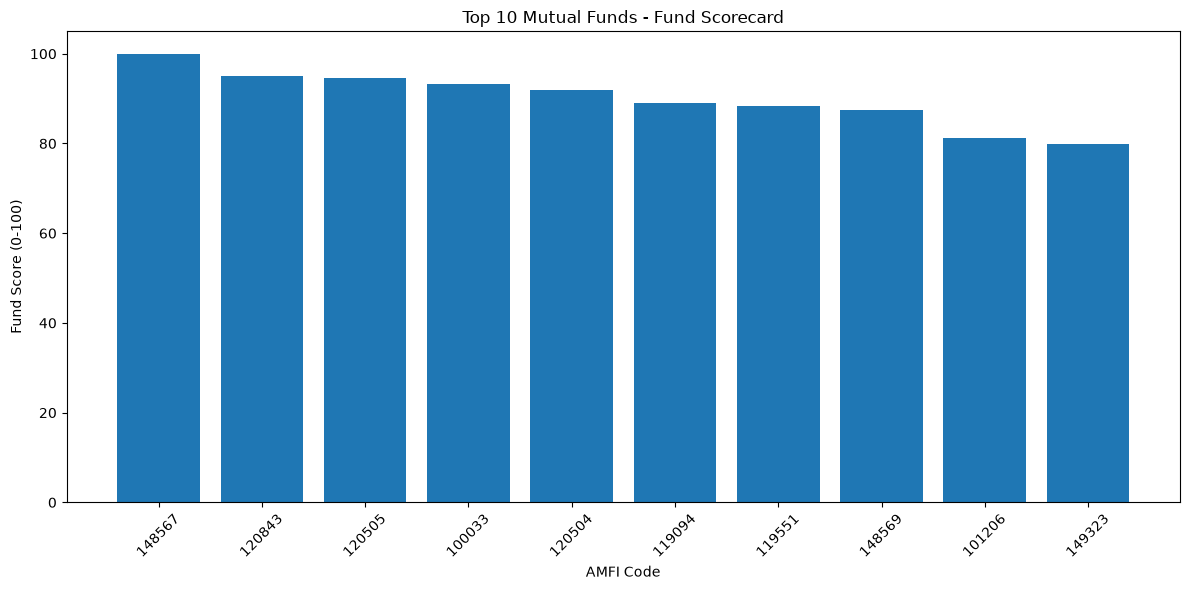

In [88]:
import matplotlib.pyplot as plt

top10 = score_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Fund_Score"]
)

plt.title("Top 10 Mutual Funds - Fund Scorecard")
plt.xlabel("AMFI Code")
plt.ylabel("Fund Score (0-100)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "reports/charts/fund_scorecard_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 8 – Benchmark Comparison & Tracking Error

## Objective

Compare the Top 5 mutual funds against NIFTY50 and NIFTY100 benchmarks over the last 3 years.

Tracking Error Formula

Tracking Error = Std(Fund Return − Benchmark Return) × √252

Deliverables

- tracking_error.csv
- benchmark_comparison.png

In [89]:
top5_funds = score_df.head(5)["amfi_code"].tolist()

top5_funds

[148567, 120843, 120505, 100033, 120504]

In [90]:
top5_funds = score_df.head(5)["amfi_code"].tolist()

top5_funds

[148567, 120843, 120505, 100033, 120504]

In [ ]:
benchmark_compare = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_compare["date"] = pd.to_datetime(
    benchmark_compare["date"]
)

benchmark_compare["benchmark_return"] = (
    benchmark_compare
    .groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_compare.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676
